<a href="https://colab.research.google.com/github/trabalhostdq-lab/ML_ANIME_SCORE/blob/main/PROJETO_ML_ANIME_COMPLETO.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

COLETA DE DADOS


In [ ]:
import requests

# 1. IDENTIFICAÇÃO
CLIENT_ID = 'ID'

def buscar_dados_anime(anime_id):
    url = f'https://api.myanimelist.net/v2/anime/{anime_id}'

    # 2. Definição de parâmetros
    campos = {
        'fields': 'id,title,mean,rank,popularity,num_list_users,num_scoring_users,genres,studios,source,average_episode_duration'
    }

    # 3. Autentificação de identidade
    headers = {
        'X-MAL-CLIENT-ID': CLIENT_ID
    }

    # 4. A Requisição Real
    response = requests.get(url, headers=headers, params=campos)

    # 5. Verificação de Erro
    if response.status_code == 200:
        return response.json()
    else:
        return f"Erro: {response.status_code} - {response.text}"

dados = buscar_dados_anime(1)
print(dados)

{'id': 1, 'title': 'Cowboy Bebop', 'main_picture': {'medium': 'https://cdn.myanimelist.net/images/anime/4/19644.jpg', 'large': 'https://cdn.myanimelist.net/images/anime/4/19644l.jpg'}, 'mean': 8.75, 'rank': 47, 'popularity': 42, 'num_list_users': 2034960, 'num_scoring_users': 1050853, 'genres': [{'id': 1, 'name': 'Action'}, {'id': 50, 'name': 'Adult Cast'}, {'id': 46, 'name': 'Award Winning'}, {'id': 24, 'name': 'Sci-Fi'}, {'id': 29, 'name': 'Space'}], 'studios': [{'id': 14, 'name': 'Sunrise'}], 'source': 'original', 'average_episode_duration': 1440}


In [ ]:
import requests
import pandas as pd
import time


CLIENT_ID = 'ID'

def coletar_top_animes(limit=2000):
    url = 'https://api.myanimelist.net/v2/anime/ranking'
    headers = {'X-MAL-CLIENT-ID': CLIENT_ID}

    lista_final = []
    offset = 0

    print(f"Iniciando coleta de {limit} animes...")

    while offset < limit:
        params = {
            'ranking_type': 'all',
            'limit': 100,
            'offset': offset,
            'fields': 'mean,genres,studios,source,num_list_users,popularity'
        }

        response = requests.get(url, headers=headers, params=params)

        if response.status_code == 200:
            dados = response.json()
            for item in dados['data']:
                node = item['node']


                info = {
                    'title': node.get('title'),
                    'score': node.get('mean'),
                    'source': node.get('source'),
                    'popularity': node.get('popularity'),
                    'members': node.get('num_list_users'),

                    'main_studio': node['studios'][0]['name'] if node.get('studios') else 'Unknown',
                    'genres': [g['name'] for g in node.get('genres', [])]
                }
                lista_final.append(info)

            offset += 100
            print(f"Coletados: {offset}...")
            time.sleep(1)
        else:
            print(f"Erro na requisição: {response.status_code}")
            break


    df = pd.DataFrame(lista_final)
    df.to_csv('dados_animes.csv', index=False)
    print("Arquivo 'dados_animes.csv' gerado com sucesso!")

coletar_top_animes(2000)

Iniciando coleta de 2000 animes...
Coletados: 100...
Coletados: 200...
Coletados: 300...
Coletados: 400...
Coletados: 500...
Coletados: 600...
Coletados: 700...
Coletados: 800...
Coletados: 900...
Coletados: 1000...
Coletados: 1100...
Coletados: 1200...
Coletados: 1300...
Coletados: 1400...
Coletados: 1500...
Coletados: 1600...
Coletados: 1700...
Coletados: 1800...
Coletados: 1900...
Coletados: 2000...
Arquivo 'dados_animes.csv' gerado com sucesso!


**TRATAMENTO DE DADOS**

In [ ]:
import pandas as pd
from sklearn.preprocessing import MultiLabelBinarizer


df = pd.read_csv('dados_animes.csv')


df = df.dropna(subset=['score'])


import ast
df['genres'] = df['genres'].apply(ast.literal_eval)


mlb = MultiLabelBinarizer()
generos_expandidos = mlb.fit_transform(df['genres'])
df_generos = pd.DataFrame(generos_expandidos, columns=mlb.classes_, index=df.index)


df_final = pd.concat([df[['score', 'popularity', 'members']], df_generos], axis=1)

print("Dados prontos para o ML!")
print(f"Tamanho da base: {df_final.shape}")
df_final.head()

Dados prontos para o Machine Learning!
Tamanho da base: (2000, 79)


,score,popularity,members,Action,Adult Cast,Adventure,Anthropomorphic,Avant Garde,Award Winning,Boys Love,...,Survival,Suspense,Team Sports,Time Travel,Urban Fantasy,Vampire,Video Game,Villainess,Visual Arts,Workplace
0,9.28,109,1342946,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9.19,673,397451,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,9.10,663,404131,1,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
3,9.10,3,3640214,1,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,9.07,14,2782502,0,0,0,0,0,0,0,...,0,1,0,1,0,0,0,0,0,0


**CONFIGURANDO ML RANDOMFOREST**


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error


y = df_final['score']
X = df_final.drop(columns=['score'])


X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, test_size=0.2, random_state=42)


modelo = RandomForestRegressor(n_estimators=100, random_state=42)


print("Treinando o modelo... aguarde.")
modelo.fit(X_treino, y_treino)


previsoes = modelo.predict(X_teste)
erro = mean_absolute_error(y_teste, previsoes)

print(f"Treino concluído!")
print(f"Erro Médio Absoluto : {erro:.2f}")

Treinando o modelo... aguarde.
Treino concluído!
Erro Médio Absoluto (MAE): 0.23


**CONFIGURANDO ML REGRESSÃO LINEAR**

Novo Erro Médio (MAE) da Regressão Linear: 0.24


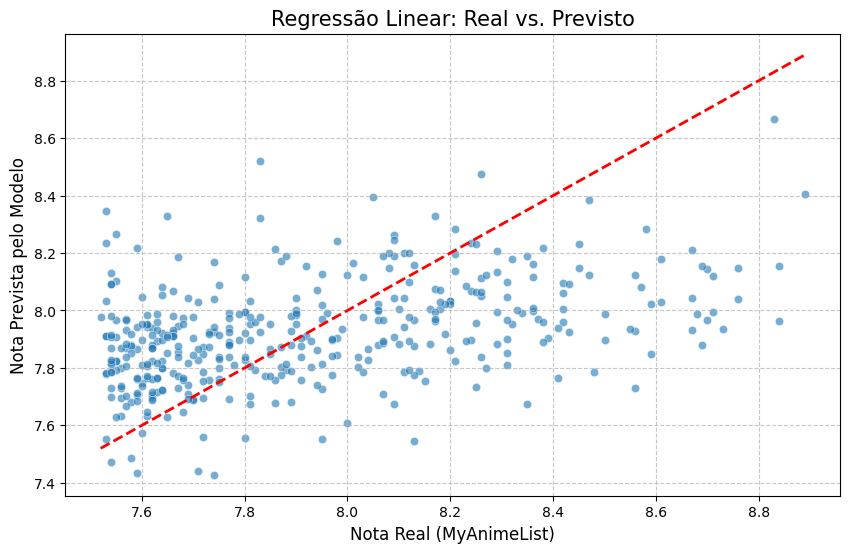

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error


scaler = StandardScaler()
X_treino_scaled = scaler.fit_transform(X_treino)
X_teste_scaled = scaler.transform(X_teste)


modelo_lr_otimizado = LinearRegression()
modelo_lr_otimizado.fit(X_treino_scaled, y_treino)

# Previsão
previsoes_lr = modelo_lr_otimizado.predict(X_teste_scaled)
erro_lr = mean_absolute_error(y_teste, previsoes_lr)

print(f"Novo Erro Médio (MAE) da Regressão Linear: {erro_lr:.2f}")


plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_teste, y=previsoes_lr, alpha=0.6)
plt.plot([y_teste.min(), y_teste.max()], [y_teste.min(), y_teste.max()], '--r', linewidth=2)

plt.title('Regressão Linear: Real vs. Previsto', fontsize=15)
plt.xlabel('Nota Real (MyAnimeList)', fontsize=12)
plt.ylabel('Nota Prevista pelo Modelo', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

**CONFIGURANDO ML XGBOOST**


In [ ]:
import xgboost as xgb


modelo_xgb = xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
modelo_xgb.fit(X_treino, y_treino)


previsoes_xgb = modelo_xgb.predict(X_teste)
erro_xgb = mean_absolute_error(y_teste, previsoes_xgb)

print(f"Erro Médio Absoluto (MAE) - XGBoost: {erro_xgb:.2f}")

Erro Médio Absoluto (MAE) - XGBoost: 0.23


## **PREDIÇÃO REAL**


In [ ]:
import pandas as pd
import numpy as np

def simulador_de_nota():
    print("---  SIMULADOR DE PREVISÃO DE ANIME ---")


    pop = int(input("Qual a popularidade estimada? (Ex: 500): "))
    memb = int(input("Quantos membros estimados? (Ex: 100000): "))
    print(f"Gêneros disponíveis: {list(mlb.classes_)}")
    generos_escolhidos = input("Digite os gêneros separados por vírgula (Ex: Action, Sci-Fi): ").split(', ')


    dados_novos = pd.DataFrame(0, index=[0], columns=X.columns)


    dados_novos['popularity'] = pop
    dados_novos['members'] = memb


    for g in generos_escolhidos:
        if g in dados_novos.columns:
            dados_novos[g] = 1
        else:
            print(f"⚠️ Aviso: O gênero '{g}' não foi encontrado na base de treino e será ignorado.")


    nota_rf = modelo.predict(dados_novos)[0]

    print("\n" + "="*30)
    print(f" PREVISÃO DO RANDOM FOREST: {nota_rf:.2f}")
    print("="*30)
    print("Lembre-se: O modelo foi treinado com base no Top 500. Caso o anime analisado esteja em uma colocação mais abaixo,\nesta nota pode estar superestimada!")


simulador_de_nota()

--- 🔮 SIMULADOR DE PREVISÃO DE ANIME ---
Qual a popularidade estimada? (Ex: 500): 1059
Quantos membros estimados? (Ex: 100000): 264023
Gêneros disponíveis: ['Action', 'Adult Cast', 'Adventure', 'Anthropomorphic', 'Avant Garde', 'Award Winning', 'Boys Love', 'CGDCT', 'Childcare', 'Combat Sports', 'Comedy', 'Crossdressing', 'Delinquents', 'Detective', 'Drama', 'Ecchi', 'Educational', 'Fantasy', 'Gag Humor', 'Girls Love', 'Gore', 'Gourmet', 'Harem', 'High Stakes Game', 'Historical', 'Horror', 'Idols (Female)', 'Idols (Male)', 'Isekai', 'Iyashikei', 'Josei', 'Kids', 'Love Polygon', 'Love Status Quo', 'Magical Sex Shift', 'Mahou Shoujo', 'Martial Arts', 'Mecha', 'Medical', 'Military', 'Music', 'Mystery', 'Mythology', 'Organized Crime', 'Otaku Culture', 'Parody', 'Performing Arts', 'Pets', 'Psychological', 'Racing', 'Reincarnation', 'Reverse Harem', 'Romance', 'Samurai', 'School', 'Sci-Fi', 'Seinen', 'Shoujo', 'Shounen', 'Showbiz', 'Slice of Life', 'Space', 'Sports', 'Strategy Game', 'Super 